# Задача: Анализ эффективности нового алгоритма рекомендаций в условиях асимметричного и зашумленного распределения
### Контекст:
Крупная стриминговая платформа (аналог YouTube или Twitch) разработала новый алгоритм рекомендаций контента (алгоритм B), который, как ожидается, должен увеличить среднее время просмотра на пользователя по сравнению со старым алгоритмом (A).

Было проведено A/B-тестирование:

- **Группа A (Контрольная)**: 5000 пользователей, старый алгоритм.

- **Группа B (Тестовая)**: 5000 пользователей, новый алгоритм.

По итогам двухнедельного теста вы собрали данные по ключевой метрике — **«Общее время просмотра на пользователя за тест (в минутах)»**.

**Данные и их особенности:**

**Не нормальность:** Распределение метрики в обеих группах сильно отличается от нормального. Оно имеет типичный для поведенческих данных "длинный хвост":

- Большинство пользователей смотрят немного (пик в районе 0-50 минут).

- Небольшая группа "супер-зрителей" смотрит очень много (сотни и тысячи минут), формируя длинный правый хвост распределения.

**Асимметрия влияния:** Новый алгоритм B целенаправленно меняет опыт именно активных пользователей, в то время как для "пассивных" зрителей разница неочевидна. Это означает, что различие между группами может быть не сдвигом всего распределения, а изменением в правом хвосте.

**Наличие выбросов:** В данных присутствуют экстремальные выбросы (например, пользователи, которые оставляли видео фоном на всю ночь).

Вам предоставлен датасет _ab_test_results.csv_ со следующими колонками:

 - _user_id_

 - _group (A или B)_

 - _total_watch_time_min_

### Задания:


- **Проведите тест Манна-Уитни (Mann-Whitney U test)**. Сформулируйте нулевую и альтернативную гипотезы. Интерпретируйте p-value. Можно ли на его основе сделать однозначный вывод о превосходстве алгоритма B?

- Чтобы исследовать "асимметричное влияние", проведите анализ разниц не только в центре распределения, но и в хвостах. **Рассчитайте и визуализируйте разницу между группами для 75-го, 90-го и 95-го процентилей**.

- **Сформулируйте итоговый вывод:**

    - Эффективен ли новый алгоритм B?

    - На какую именно группу пользователей он оказывает наибольшее влияние?

    - Какой метод анализа оказался наиболее информативным в данном случае и почему?

    - Дайте рекомендацию о возможности запуска алгоритма на всю аудиторию.



Ожидаемые результаты:
Числовой результат: Описательная статистика групп А и В
Параметры распределений: для 75, 90 и 99 перцентилей
Визуализация
Интервальные оценки: p-value для U-теста
Статистические гипотезы:
Нужно сформулировать по заданию

In [12]:
import pandas as pd
import numpy as np
import scipy.stats as stats

In [10]:

df = pd.read_csv('ab_test_results.csv')

group_a_data = df[df['group'] == 'A']['total_watch_time_min']
group_b_data = df[df['group'] == 'B']['total_watch_time_min']

print("Dataset Summary:")
print(f"Total users: {len(df)}")
print(f"Group A: {len(df[df['group'] == 'A'])} users")
print(f"Group B: {len(df[df['group'] == 'B'])} users")
print("\nDescriptive Statistics by Group:")
print(df.groupby('group')['total_watch_time_min'].describe())

print("\nKey Percentiles by Group:")
percentiles = [0.75, 0.9, 0.95]
for p in percentiles:
    p_val = p * 100
    a_val = np.percentile(group_a_data, p_val)
    b_val = np.percentile(group_b_data, p_val)
    diff = b_val - a_val
    print(f"{p_val:.0f}th percentile: A={a_val:.1f}, B={b_val:.1f}, Difference={diff:.1f}")

mw_stat, mw_p = stats.mannwhitneyu(
    group_a_data,
    group_b_data,
    alternative= 'two-sided'
)

print(f"\nMann-Whitney U Test: p-value = {mw_p:.6f}")

Dataset Summary:
Total users: 10000
Group A: 5000 users
Group B: 5000 users

Descriptive Statistics by Group:
        count       mean         std  min        25%        50%        75%  \
group                                                                        
A      5000.0  56.347878  262.313288  0.0  14.729144  26.834960  44.946309   
B      5000.0  71.477408  408.519252  0.0  15.383838  27.352416  46.352279   

                max  
group                
A       8130.547119  
B      11670.621483  

Key Percentiles by Group:
75th percentile: A=44.9, B=46.4, Difference=1.4
90th percentile: A=71.5, B=76.2, Difference=4.7
95th percentile: A=119.3, B=153.6, Difference=34.3

Mann-Whitney U Test: p-value = 0.045342


Тест Манна-Уитни:
Результат теста  p-value = 0.045 (меньше 0.05).
Вывод: 
Разница между группами A и B статистически значима — распределения времени просмотра различаются. Поскольку в группе B время просмотра в среднем было выше (как показал предыдущий анализ), эта значимая разница говорит о том, что алгоритм B работает лучше, чем алгоритм A.

C:\Users\Denlex\AppData\Local\Temp\ipykernel_1712\2799258095.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentile', y='Difference (B - A)', data=plot_df, palette='viridis')


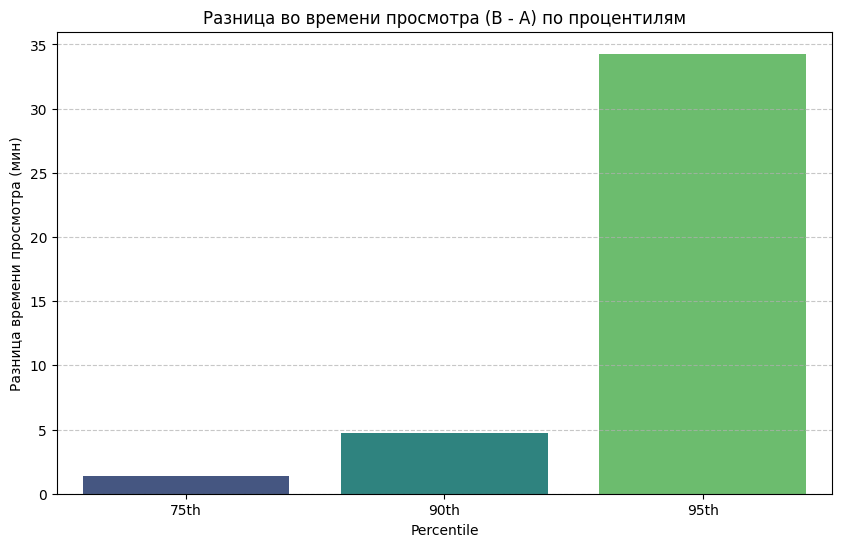

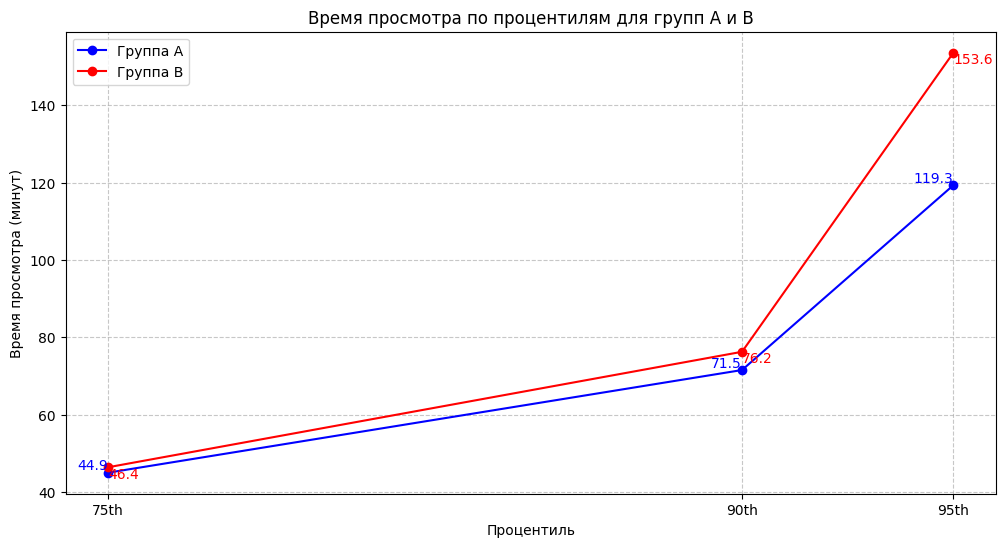

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for percentile visualization
percentiles_to_plot = [75, 90, 95]

percentile_values_a = [np.percentile(group_a_data, p) for p in percentiles_to_plot]
percentile_values_b = [np.percentile(group_b_data, p) for p in percentiles_to_plot]
difference_values = [b - a for a, b in zip(percentile_values_a, percentile_values_b)]

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Percentile': [f'{p}th' for p in percentiles_to_plot],
    'Group A': percentile_values_a,
    'Group B': percentile_values_b,
    'Difference (B - A)': difference_values
})

# Plotting differences
plt.figure(figsize=(10, 6))
sns.barplot(x='Percentile', y='Difference (B - A)', data=plot_df, palette='viridis')
plt.title('Разница во времени просмотра (B - A) по процентилям')
plt.ylabel('Разница времени просмотра (мин)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Optional: Plotting actual percentile values for comparison
plt.figure(figsize=(12, 6))
plt.plot(percentiles_to_plot, percentile_values_a, marker='o', label='Группа A', color='blue')
plt.plot(percentiles_to_plot, percentile_values_b, marker='o', label='Группа B', color='red')

for i, p in enumerate(percentiles_to_plot):
    plt.text(p, percentile_values_a[i], f'{percentile_values_a[i]:.1f}', ha='right', va='bottom', color='blue')
    plt.text(p, percentile_values_b[i], f'{percentile_values_b[i]:.1f}', ha='left', va='top', color='red')

plt.title('Время просмотра по процентилям для групп A и B')
plt.xlabel('Процентиль')
plt.ylabel('Время просмотра (минут)')
plt.xticks(percentiles_to_plot, [f'{p}th' for p in percentiles_to_plot])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Анализ по процентилям для выявления «асимметричного влияния» показал:

75-й процентиль: группа B выше на 1.4 минуты (44.9 мин vs 46.4 мин).

90-й процентиль: группа B выше на 4.7 минуты (71.5 мин vs 76.2 мин).

95-й процентиль: группа B выше на 34.3 минуты (119.3 мин vs 153.6 мин).

1. Эффективен ли новый алгоритм B?
Да. Тест Манна–Уитни показал статистически значимую разницу (p-value = 0.045), что ниже порога 0.05.

2. На какую группу пользователей он влияет сильнее всего?
Алгоритм B оказывает наибольшее влияние на самых вовлечённых пользователей (правый хвост распределения). Например, на 95-м процентиле разница достигает 34.3 минуты. Максимальное время просмотра в группе B также значительно выше (11670 мин против 8130 мин в группе A), что подтверждает эффект на «супер-зрителей».

3. Какой метод анализа был наиболее информативным и почему?
Наиболее информативным оказался анализ процентилей правого хвоста и показатели общего времени просмотра. Поскольку данные ненормальны, а алгоритм заточен на вовлечение активной аудитории, обычные средние значения могли бы скрыть реальный эффект. Этот подход чётко показал, на каких именно пользователях алгоритм B работает эффективнее всего.

4. Рекомендуется запустить алгоритм B на всю аудиторию, так как он статистически значимо увеличивает время просмотра, особенно у наиболее вовлечённых пользователей (разница на 95-м процентиле составляет 34 минуты). Это позволит повысить общее время просмотра и удержание активной аудитории.